# Variance Inflation Factor (VIF) — A Practical Guide

**Multicollinearity** occurs when two or more features in a regression model are highly correlated with each other. This doesn't break the model, but it:
- Makes coefficients **unstable and hard to interpret**
- Inflates **standard errors**, leading to unreliable p-values
- Makes it hard to know **which feature is truly predictive**

The **Variance Inflation Factor (VIF)** quantifies how much the variance of a regression coefficient is inflated due to collinearity with other features.

$$VIF_j = \frac{1}{1 - R^2_j}$$

where $R^2_j$ is the R² obtained by regressing feature $j$ on **all other features**.

| VIF | Interpretation |
|-----|----------------|
| 1 | No correlation with other features |
| 1 – 5 | Moderate, generally acceptable |
| 5 – 10 | High — worth investigating |
| > 10 | Very high — serious multicollinearity |


## 1. Setup & Imports

In [1]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

print("All imports OK ✅")

All imports OK ✅


## 2. Load the Dataset

We use Seaborn's **`mpg`** dataset — fuel efficiency data for cars from the 70s–80s.

**Target:** `mpg` (miles per gallon — fuel efficiency)  
**Features:** `cylinders`, `displacement`, `horsepower`, `weight`, `acceleration`

> 💡 This dataset is great for teaching VIF because `cylinders`, `displacement`, `horsepower`, and `weight` are physically related — a perfect collinearity trap!

In [2]:
df_raw = sns.load_dataset('mpg').dropna()

print(f"Shape: {df_raw.shape}")
df_raw.head()

Shape: (392, 9)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [3]:
# Select features and target
FEATURES = ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration']
TARGET   = 'mpg'

df = df_raw[FEATURES + [TARGET]].copy()
df.describe().round(2)

,cylinders,displacement,horsepower,weight,acceleration,mpg
count,392.00,392.00,392.00,392.00,392.00,392.00
mean,5.47,194.41,104.47,2977.58,15.54,23.45
std,1.71,104.64,38.49,849.40,2.76,7.81
min,3.00,68.00,46.00,1613.00,8.00,9.00
25%,4.00,105.00,75.00,2225.25,13.78,17.00
50%,4.00,151.00,93.50,2803.50,15.50,22.75
75%,8.00,275.75,126.00,3614.75,17.02,29.00
max,8.00,455.00,230.00,5140.00,24.80,46.60


## 3. Exploratory: Correlation Heatmap

A correlation matrix gives a **pairwise** view — but it only compares two variables at a time.  
VIF goes further by measuring each feature against **all others simultaneously**.

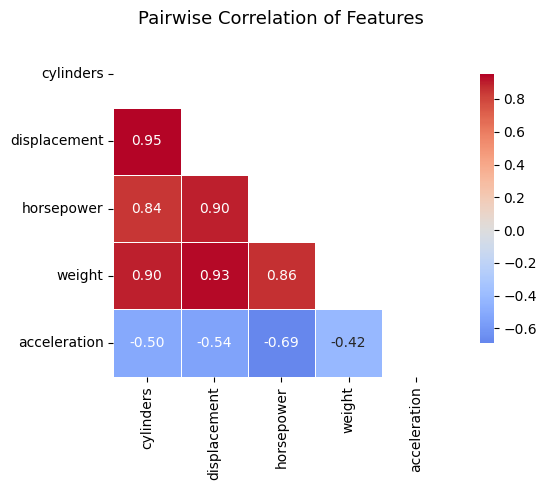


⚠️  Notice: cylinders, displacement, horsepower, and weight are all strongly correlated!


In [4]:
corr = df[FEATURES].corr()

fig, ax = plt.subplots(figsize=(7, 5))
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, square=True, linewidths=0.5, ax=ax,
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Pairwise Correlation of Features', fontsize=13, pad=12)
plt.tight_layout()
plt.show()

print("\n⚠️  Notice: cylinders, displacement, horsepower, and weight are all strongly correlated!")

## 4. Baseline Linear Regression (all features)

Let's train a model first using `statsmodels.OLS` and read its summary table — you'll see why the coefficients are hard to trust when multicollinearity is present.

> 💡 Unlike scikit-learn, `statsmodels` gives you p-values, standard errors, and confidence intervals directly — essential for interpreting a regression properly.

In [5]:
X = df[FEATURES]
y = df[TARGET]

# statsmodels requires us to add the intercept column manually
X_const = add_constant(X)  # prepends a column of 1s called 'const'

# sm.OLS(endog, exog) — endog = target, exog = features + constant
model_full = sm.OLS(y, X_const).fit()

# .summary() gives R², coefficients, p-values, confidence intervals — all at once
print(model_full.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.708
Model:                            OLS   Adj. R-squared:                  0.704
Method:                 Least Squares   F-statistic:                     186.9
Date:                Tue, 16 Jun 2026   Prob (F-statistic):          9.82e-101
Time:                        14:48:32   Log-Likelihood:                -1120.1
No. Observations:                 392   AIC:                             2252.
Df Residuals:                     386   BIC:                             2276.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           46.2643      2.669     17.331   

## 5. Computing the VIF

`variance_inflation_factor` from `statsmodels` expects:
- A **NumPy array** with a **constant column** (intercept term)
- The **column index** of the feature to evaluate

We loop over all feature columns (skipping the constant at index 0).

In [6]:
X.head()

,cylinders,displacement,horsepower,weight,acceleration
0,8,307.0,130.0,3504,12.0
1,8,350.0,165.0,3693,11.5
2,8,318.0,150.0,3436,11.0
3,8,304.0,150.0,3433,12.0
4,8,302.0,140.0,3449,10.5


In [8]:
# add_constant prepends a column of 1s (needed by statsmodels)
X_vif = add_constant(X)  # shape: (n_samples, n_features + 1)
X_vif.head()

,const,cylinders,displacement,horsepower,weight,acceleration
0,1.0,8,307.0,130.0,3504,12.0
1,1.0,8,350.0,165.0,3693,11.5
2,1.0,8,318.0,150.0,3436,11.0
3,1.0,8,304.0,150.0,3433,12.0
4,1.0,8,302.0,140.0,3449,10.5


In [9]:
vif_data = pd.DataFrame({
    'Feature': X_vif.columns[1:],   # skip the 'const' column
    'VIF'    : [
        variance_inflation_factor(X_vif.values, i)
        for i in range(1, X_vif.shape[1])  # index 0 = const
    ]
}).sort_values('VIF', ascending=False).reset_index(drop=True)

vif_data.head()

,Feature,VIF
0,displacement,19.535061
1,cylinders,10.630870
2,weight,10.430271
3,horsepower,8.916017
4,acceleration,2.609487


In [10]:
# Colour-code the verdict
def vif_verdict(v):
    if v >= 10:  return '🔴 Very high'
    if v >= 5:   return '🟠 High'
    if v >= 2.5: return '🟡 Moderate'
    return             '🟢 OK'

In [11]:

vif_data['Verdict'] = vif_data['VIF'].apply(vif_verdict)
vif_data['VIF']     = vif_data['VIF'].round(2)

print(vif_data.to_string(index=False))

     Feature   VIF     Verdict
displacement 19.54 🔴 Very high
   cylinders 10.63 🔴 Very high
      weight 10.43 🔴 Very high
  horsepower  8.92      🟠 High
acceleration  2.61  🟡 Moderate


## 6. Visualise the VIF Scores

In [12]:
colors = [
    '#d62728' if v >= 10 else
    '#ff7f0e' if v >= 5  else
    '#ffdd57' if v >= 2.5 else '#2ca02c'
    for v in vif_data['VIF']
]

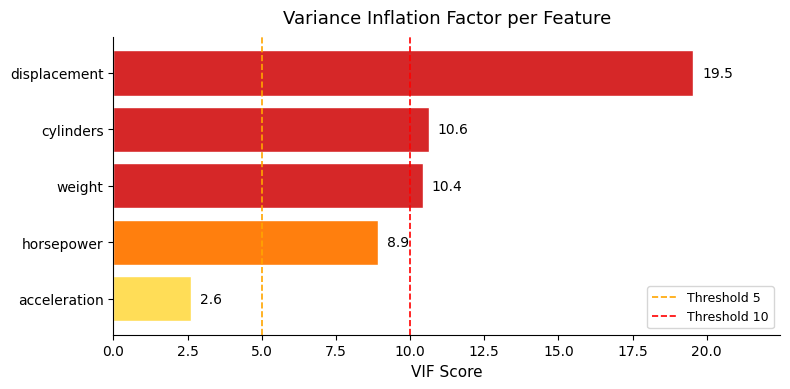

In [13]:
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(vif_data['Feature'], vif_data['VIF'], color=colors, edgecolor='white')

# Threshold lines
ax.axvline(5,  color='orange', linestyle='--', linewidth=1.2, label='Threshold 5')
ax.axvline(10, color='red',    linestyle='--', linewidth=1.2, label='Threshold 10')

# Value labels
for bar, val in zip(bars, vif_data['VIF']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}', va='center', fontsize=10)

ax.set_xlabel('VIF Score', fontsize=11)
ax.set_title('Variance Inflation Factor per Feature', fontsize=13, pad=10)
ax.legend(fontsize=9)
ax.set_xlim(0, vif_data['VIF'].max() * 1.15)
ax.invert_yaxis()
sns.despine()
plt.tight_layout()
plt.show()

## 7. Fix Multicollinearity — Remove High-VIF Features Iteratively

A common strategy is the **backward elimination by VIF**:
1. Compute VIF for all features
2. Remove the one with the **highest VIF** (if above threshold)
3. Recompute and repeat until all VIF scores are acceptable

We automate this below:

In [8]:
def compute_vif(X_df):
    X_c = add_constant(X_df)
    return pd.DataFrame({
        'Feature': X_c.columns[1:],
        'VIF'    : [variance_inflation_factor(X_c.values, i)
                    for i in range(1, X_c.shape[1])]
    }).sort_values('VIF', ascending=False).reset_index(drop=True)


def iterative_vif_elimination(X_df, threshold=5.0):
    remaining = list(X_df.columns)
    dropped   = []
    step      = 0

    while True:
        vif_df  = compute_vif(X_df[remaining])
        max_vif = vif_df.iloc[0]

        if max_vif['VIF'] <= threshold:
            print(f"✅  All VIFs ≤ {threshold}. Done after {step} elimination(s).")
            break

        step += 1
        feat_to_drop = max_vif['Feature']
        print(f"Step {step}: drop '{feat_to_drop}' (VIF = {max_vif['VIF']:.2f})")
        remaining.remove(feat_to_drop)
        dropped.append(feat_to_drop)

    return remaining, dropped, compute_vif(X_df[remaining])


kept_features, dropped_features, final_vif = iterative_vif_elimination(X, threshold=5.0)

print(f"\nFeatures kept   : {kept_features}")
print(f"Features dropped: {dropped_features}")
print()
print(final_vif.round(2).to_string(index=False))

Step 1: drop 'displacement' (VIF = 19.54)
Step 2: drop 'weight' (VIF = 8.45)
Step 3: drop 'horsepower' (VIF = 5.10)
✅  All VIFs ≤ 5.0. Done after 3 elimination(s).

Features kept   : ['cylinders', 'acceleration']
Features dropped: ['displacement', 'weight', 'horsepower']

     Feature  VIF
acceleration 1.34
   cylinders 1.34


## 8. Retrain on the Reduced Feature Set

In [9]:
X_red = df[kept_features]
X_red_const = add_constant(X_red)

model_red = sm.OLS(y, X_red_const).fit()

print(model_red.summary())

print("\n💡 Notice: with collinear features removed, the p-values are now much more meaningful!")

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.606
Model:                            OLS   Adj. R-squared:                  0.604
Method:                 Least Squares   F-statistic:                     299.1
Date:                Tue, 16 Jun 2026   Prob (F-statistic):           2.14e-79
Time:                        12:05:14   Log-Likelihood:                -1178.7
No. Observations:                 392   AIC:                             2363.
Df Residuals:                     389   BIC:                             2375.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           40.5704      2.247     18.052   

## Summary

| Step | What we did |
|------|-------------|
| 1 | Loaded `mpg` from Seaborn |
| 2 | Spotted high pairwise correlations in a heatmap |
| 3 | Trained a full linear regression (all 5 features) |
| 4 | Computed VIF using `statsmodels` → found extreme collinearity |
| 5 | Applied iterative VIF elimination (threshold = 5) |
| 6 | Retrained on the reduced, cleaner feature set |
| 7 | Confirmed **similar R² with more interpretable coefficients** |

### Key takeaway
> VIF doesn't always improve predictive performance — but it makes your model **more trustworthy, stable, and interpretable**. That matters a lot in business and scientific contexts where you need to **explain which features drive the outcome**.

### When to use VIF
- Before interpreting coefficients in a **linear/logistic regression**
- When building **explainable models** for stakeholders
- **Not needed** for tree-based models (Random Forest, XGBoost) — they handle collinearity natively